# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

- 데이터 처리를 위한 Pandas와 그래프를 그리기 위한 Matplotlib 라이브러리 불러오기

- from collections import Counter: 요소의 개수를 쉽게 세어주는 파이썬 기본 모듈 (데이터 집계)

- %matplotlib inline: 주피터 노트북 환경에서 plt.show() 호출 시 그래프가 팝업창이 아닌 코드 셀 바로 밑에 출력

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [5]:
url="https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
chipo=pd.read_csv(url, sep='\t')

파일이 탭으로 구분되어 있으므로 sep='\t'을 옵션으로 준다.

### Step 4. See the first 10 entries

In [6]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

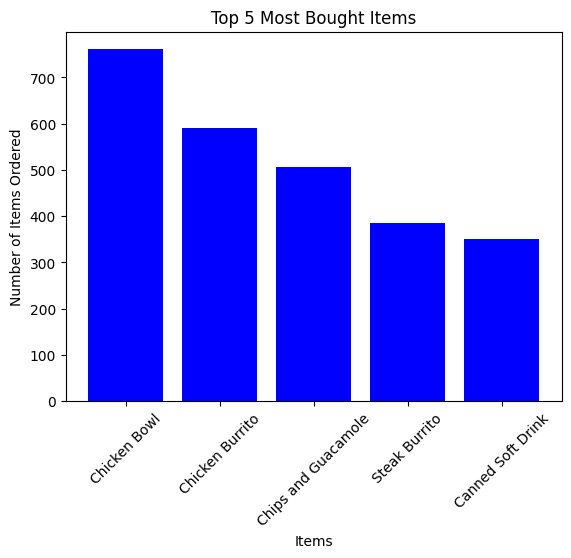

In [8]:
# 아이템별 수량을 합산하여 상위 5개 선택
top5=chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(5)

# 막대그래프 시각화
plt.bar(top5.index, top5.values, color='blue')
plt.title('Top 5 Most Bought Items')
plt.xlabel('Items')
plt.ylabel('Number of Items Ordered')
plt.xticks(rotation=45)
plt.show()

item_name 기준으로 그룹화해 주문 수량(quantity)을 합산한 후, 가장 많이 팔린 상위 5개 제품을 막대그래프로 표현

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

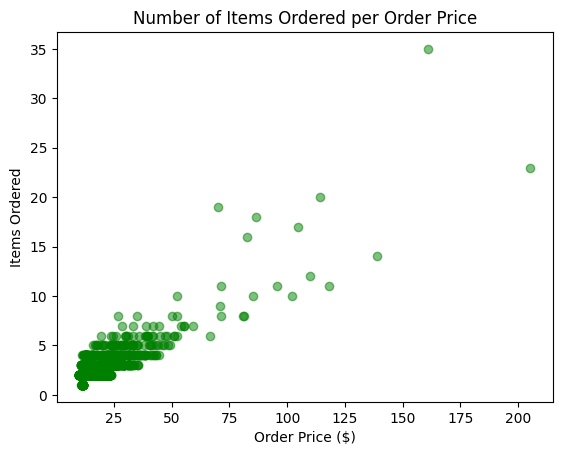

In [9]:
# item_price에서 '$' 기호를 제거하고 float 타입으로 변환
chipo['item_price_clean'] = chipo['item_price'].str.replace('$', '').astype(float)

# 주문번호(order_id)별 총 가격과 총 주문 수량 계산
orders = chipo.groupby('order_id').agg({'item_price_clean': 'sum', 'quantity': 'sum'})

# 산점도 시각화 (X축: Price, Y축: Items)
plt.scatter(x=orders['item_price_clean'], y=orders['quantity'], alpha=0.5, color='green')
plt.title('Number of Items Ordered per Order Price')
plt.xlabel('Order Price ($)')
plt.ylabel('Items Ordered')
plt.show()

1. 문자열 상태인 item_price의 $ 기호를 제거한 뒤 숫자로 변환
2. 주문번호(order_id) 단위로 총 가격과 수량을 합산해 가격대별 구매 수량 관계를 산점도 그리기

### Step 7. BONUS: Create a question and a graph to answer your own question.

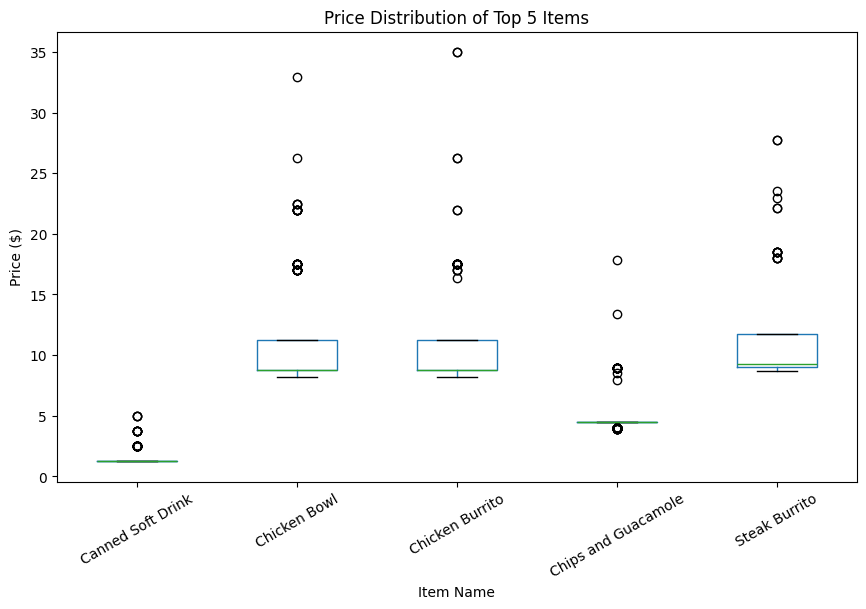

In [11]:
# 질문: 치폴레에서 가장 많이 판매되는 상위 5개 아이템의 가격 분포

# 상위 5개 아이템 데이터만 필터링
top5_names = top5.index
top5_df = chipo[chipo['item_name'].isin(top5_names)]

# 아이템별 가격 분포를 박스플롯(Boxplot)으로 시각화
top5_df.boxplot(column='item_price_clean', by='item_name', grid=False, figsize=(10, 6))
plt.title('Price Distribution of Top 5 Items')
plt.suptitle('')  # 자동 생성되는 판다스 타이틀 제거
plt.xlabel('Item Name')
plt.ylabel('Price ($)')
plt.xticks(rotation=30)
plt.show()

인기 아이템 상위 5개 제품 각각의 단가 범위 & 옵션 추가에 따른 가격 변동 폭을 알아보기 위해 박스플롯(Boxplot)을 활용함

분석 결과, 치폴레의 상위 5개 인기 메뉴는 대부분 $8~$11 선의 기본 가격대를 형성하고 있습니다. 다만 스테이크나 옵션 추가에 따라 일부 주문은 최대 $20 이상까지 가격이 상승하는 변동성을 보임